Download file if not downloaded yet

In [8]:
import requests

url = "https://upload.wikimedia.org/wikipedia/commons/a/af/Golden_retriever_eating_pigs_foot.jpg"

headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)

if response.status_code == 200:
    with open("dog.jpg", "wb") as f:
        f.write(response.content)
    print("Image was saved as 'dog.jpg'")
else:
  print(f"Failed to download the file: status {response.status_code}")


Image was saved as 'dog.jpg'


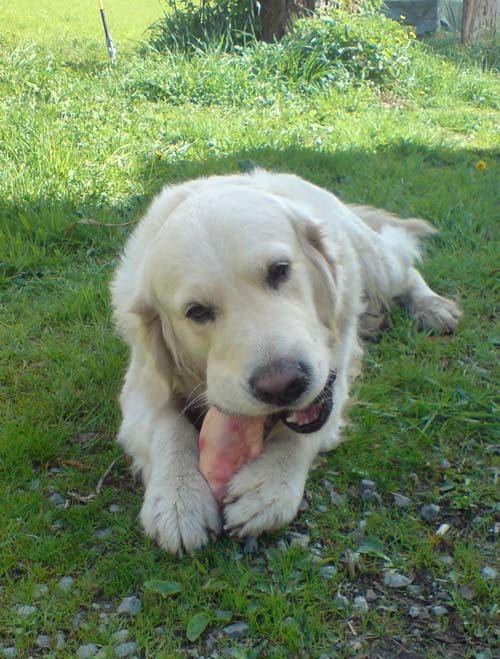

In [9]:
from PIL import Image
from IPython.display import display

img = Image.open("dog.jpg")
display(img)

Draw a frame and text on the picture

Loaded font: C:\WINDOWS\Fonts\arial.ttf


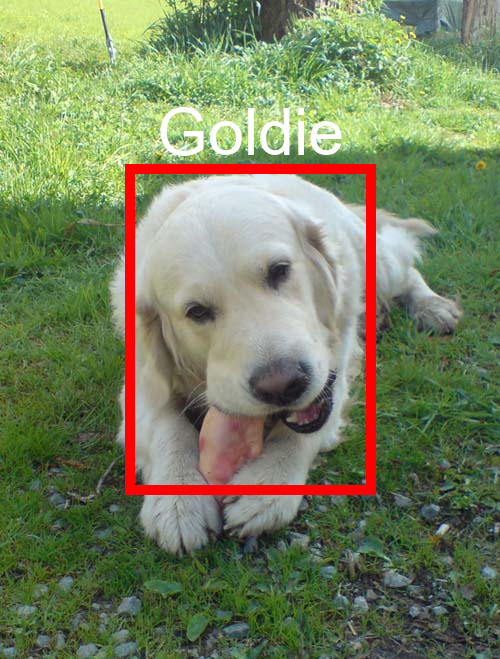

In [10]:
import os
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

# 1. Load the image
draw = ImageDraw.Draw(img)
width, height = img.size

# 2. Define coordinates for the red frame (25% from edges)
left = width * 0.25
top = height * 0.25
right = width * 0.75
bottom = height * 0.75

# 3. Draw the red rectangle (frame)
line_width = 10
draw.rectangle([left, top, right, bottom], outline="red", width=line_width)

# 4. Add text: "Goldie" (cute nickname for Golden Retriever)
nickname = "Goldie"

# Calculate font size based on image height
font_size = int(height * 0.1)

# Try to load a Windows-specific font
try:
    # Most common font on Windows is Arial
    font_path = os.path.join(os.environ['WINDIR'], 'Fonts', 'arial.ttf')
    font = ImageFont.truetype(font_path, font_size)
    print(f"Loaded font: {font_path}")
except Exception as e:
    # Fallback if the specific font is missing
    print(f"Custom font not found ({e}), using default.")
    font = ImageFont.load_default()

# Calculate text position (centered horizontally, slightly above the frame)
# Use textbbox to get dimensions of the text
bbox = draw.textbbox((0, 0), nickname, font=font)
text_width = bbox[2] - bbox[0]
text_height = bbox[3] - bbox[1]

text_x = (width - text_width) / 2
text_y = top - text_height - 20 # 20 pixels above the frame

# Draw the text on the image
draw.text((text_x, text_y), nickname, fill="white", font=font)

# Show and save result
display(img)

Draw arrow

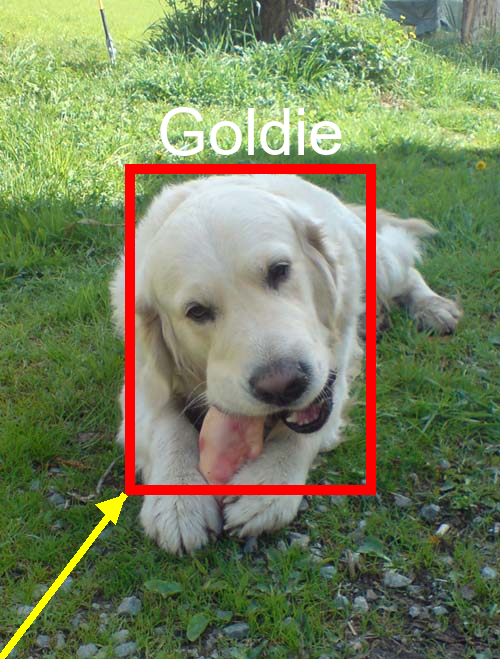

In [11]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

# Open the image
draw = ImageDraw.Draw(img)

# Arrow coordinates
# Start: Bottom-left corner of the WHOLE image
start_point = (0, height) 
# End: Bottom-left corner of the FRAME
end_point = (left, bottom)

# Draw the yellow arrow
arrow_color = "yellow"
line_width = 8

# A) Draw the main line (the shaft of the arrow)
draw.line([start_point, end_point], fill=arrow_color, width=line_width)

# B) Draw the arrowhead (a small triangle at the end_point)
# We define 3 points for the triangle to make it look like a pointer
nodes = [
    (end_point[0], end_point[1]),          # The tip of the arrow
    (end_point[0] - 30, end_point[1] + 10), # Bottom wing
    (end_point[0] - 10, end_point[1] + 30)  # Top wing
]
draw.polygon(nodes, fill=arrow_color)

# Display result
display(img)

Get pixel color

In [12]:
pixel = img.getpixel((10, 10))
pixel

(216, 236, 139)

In [13]:
pixel = img.getpixel((0, height-1))
pixel

(255, 255, 0)

Convert pixel map to array (!!!)

In [14]:
import numpy as np 
arr = np.array(img)

arr

array([[[213, 238, 146],
        [210, 235, 143],
        [203, 228, 134],
        ...,
        [160, 165, 168],
        [166, 178, 178],
        [171, 185, 185]],

       [[211, 236, 144],
        [209, 234, 142],
        [203, 228, 134],
        ...,
        [159, 164, 167],
        [164, 176, 176],
        [169, 183, 183]],

       [[207, 232, 140],
        [207, 232, 140],
        [202, 227, 135],
        ...,
        [156, 161, 164],
        [161, 173, 173],
        [165, 179, 179]],

       ...,

       [[255, 255,   0],
        [255, 255,   0],
        [255, 255,   0],
        ...,
        [ 84,  98,  99],
        [ 82,  96,  96],
        [ 80,  94,  94]],

       [[255, 255,   0],
        [255, 255,   0],
        [255, 255,   0],
        ...,
        [ 70,  80,  82],
        [ 78,  88,  90],
        [ 84,  94,  96]],

       [[255, 255,   0],
        [255, 255,   0],
        [255, 255,   0],
        ...,
        [ 51,  54,  59],
        [ 69,  72,  77],
        [ 82,  85,  90]]

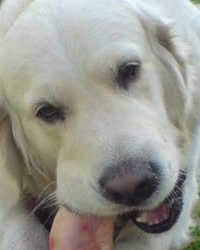

In [15]:
small_arr = arr[200:450, 150:350, :]
small_img = Image.fromarray(small_arr)
display(small_img)